In [1]:
import subprocess, sys

libs = [
    ["torch==2.1.2", "torchvision==0.16.2"],
    ["diffusers==0.31.0"],
    ["transformers==4.40.0"],
    ["accelerate==0.30.0"],
    ["numpy<2.0"],
    ["Pillow"]
]

for lib in libs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + lib)

In [2]:
import torch

device = "cpu"
dtype  = torch.float32
threads = 56

torch.set_num_threads(threads)
torch.set_num_interop_threads(threads)

print(f"Threads : {torch.get_num_threads()}")
print(f"Interop : {torch.get_num_interop_threads()}")
print(f"dtype   : {dtype}")
print("Estimated time: 10-20 min per image")

Threads : 56
Interop : 56
dtype   : torch.float32
Estimated time: 10-20 min per image


In [3]:
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    use_karras_sigmas=True
)

pipe = pipe.to(device)
pipe.enable_attention_slicing(1)

print("Model ready — CPU 56 threads")

/home/s/miniconda3/envs/sd-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 11.28it/s]

Model ready — CPU 56 threads


100%|██████████| 25/25 [03:12<00:00,  7.69s/it]


Done in 197.0s  |  saved: movsar_cpu.png


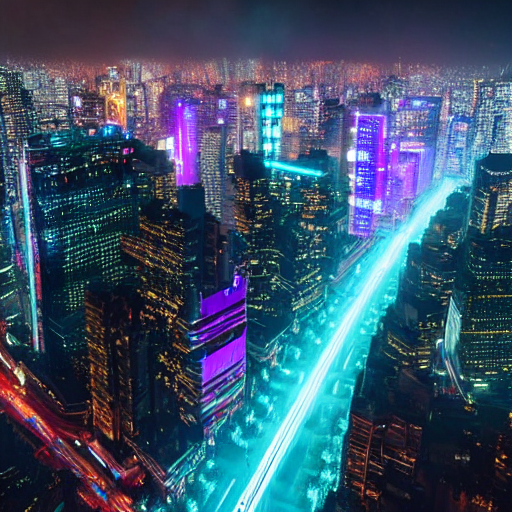

In [ ]:
import time

prompt = (
    "A sprawling cyberpunk megacity at midnight, rain-slicked streets reflecting "
    "cascades of neon signs in Cyrillic and Japanese, towering brutalist skyscrapers "
    "wrapped in holographic banners, hovercars threading between lit windows, "
    "volumetric fog, ultra-detailed, cinematic 4k, photorealistic render"
)

negative_prompt = (
    "daytime, sunny, cartoon, anime, low quality, blurry, watermark, "
    "text overlay, deformed architecture, oversaturated"
)

generator = torch.Generator(device=device).manual_seed(2077)

t0 = time.time()

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=25,
    guidance_scale=7.5,
    width=512,
    height=512,
    generator=generator
).images[0]

elapsed = time.time() - t0

image.save("m_cpu.png")
print(f"Done in {elapsed:.1f}s  |  saved: m_cpu.png")
image